# Stock Price Prediction using RNN with LSTM

**Objective:** Build a Recurrent Neural Network (RNN) using LSTM (Long Short-Term Memory) to predict future stock prices based on historical data.

**Dataset:** Historical stock price data for Apple Inc. (AAPL) from Yahoo Finance (Jan 2019 – Dec 2024)


## 1. Import Required Libraries

We import all necessary libraries for data handling, visualization, preprocessing, and building the LSTM model.

In [ ]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Deep Learning - LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Download stock data
import yfinance as yf

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)
print('All libraries imported successfully!')

TensorFlow version: 2.20.0
All libraries imported successfully!


## 2. Load the Dataset

We download Apple (AAPL) stock price data from Yahoo Finance for the period **January 1, 2019 to December 31, 2024**.

The dataset contains daily trading information including Open, High, Low, Close, Adj Close, and Volume.

In [ ]:
# Download AAPL stock data from Yahoo Finance
df = yf.download('AAPL', start='2019-01-01', end='2024-12-31')

# Reset index to make Date a column
df.reset_index(inplace=True)

# Also save a CSV copy for reference
df.to_csv('AAPL_stock_data.csv', index=False)
print(f'Dataset shape: {df.shape}')
print(f'Date range: {df["Date"].min()} to {df["Date"].max()}')
print('\nDataset saved as AAPL_stock_data.csv')

[*********************100%***********************]  1 of 1 completed

Dataset shape: (1509, 6)
Date range: 2019-01-02 00:00:00 to 2024-12-30 00:00:00

Dataset saved as AAPL_stock_data.csv


In [ ]:
# Display first 5 rows
print('=== First 5 Rows ===')
df.head()

=== First 5 Rows ===


Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2019-01-02,37.503727,37.724590,36.627404,36.784146,148158800
1,2019-01-03,33.768082,34.606406,33.722959,34.193179,365248800
2,2019-01-04,35.209610,35.278483,34.150426,34.323790,234428400
3,2019-01-07,35.131233,35.344972,34.649138,35.314098,219111200
4,2019-01-08,35.800949,36.055060,35.271357,35.518341,164101200


In [ ]:
# Dataset information
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1509 entries, 0 to 1508
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (Date, )        1509 non-null   datetime64[ns]
 1   (Close, AAPL)   1509 non-null   float64       
 2   (High, AAPL)    1509 non-null   float64       
 3   (Low, AAPL)     1509 non-null   float64       
 4   (Open, AAPL)    1509 non-null   float64       
 5   (Volume, AAPL)  1509 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 70.9 KB


In [ ]:
# Statistical summary
print('=== Statistical Summary ===')
df.describe()

=== Statistical Summary ===


Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
count,1509,1509.000000,1509.000000,1509.000000,1509.000000,1.509000e+03
mean,2021-12-30 03:19:26.600397568,134.483089,135.814046,132.988399,134.337509,9.420399e+07
min,2019-01-02 00:00:00,33.768082,34.606406,33.722959,34.193179,2.323470e+07
25%,2020-07-01 00:00:00,88.393433,89.757473,87.770787,88.432185,5.914450e+07
50%,2021-12-29 00:00:00,142.807358,144.345284,141.117033,142.660166,8.153200e+07
75%,2023-06-30 00:00:00,171.510559,172.976473,169.652235,171.351767,1.124244e+08
max,2024-12-30 00:00:00,257.612732,258.686881,256.230300,256.787255,4.265100e+08
std,NaN,53.884634,54.274496,53.417125,53.827864,5.232393e+07


## 3. Data Preprocessing

### Why do we use only the Close price?
The **Close price** represents the final price at which the stock traded during a regular trading session. It is the most commonly used feature for stock price prediction as it reflects the market's final consensus on the stock's value for that day.

### Why do we need scaling?
- LSTM networks are sensitive to the scale of input data
- **MinMaxScaler** normalizes data to a 0–1 range, which helps the model converge faster
- It prevents features with larger magnitudes from dominating the learning process
- Gradient-based optimization works better with normalized data

In [ ]:
# Check for missing values
print('=== Missing Values ===')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

=== Missing Values ===
Price   Ticker
Date              0
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

Total missing values: 0


In [ ]:
# Handle missing values (forward fill, then backward fill)
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)
print('Missing values after handling:', df.isnull().sum().sum())

Missing values after handling: 0


In [ ]:
# Extract the Close price column
close_data = df[['Close']].values  # Convert to numpy array
print(f'Close price data shape: {close_data.shape}')
print(f'Min Close price: ${close_data.min():.2f}')
print(f'Max Close price: ${close_data.max():.2f}')
print(f'Mean Close price: ${close_data.mean():.2f}')

Close price data shape: (1509, 1)
Min Close price: $33.77
Max Close price: $257.61
Mean Close price: $134.48


In [ ]:
# Normalize the data using MinMaxScaler (0 to 1 range)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_data)

print(f'Scaled data shape: {scaled_data.shape}')
print(f'Scaled data range: [{scaled_data.min():.4f}, {scaled_data.max():.4f}]')

Scaled data shape: (1509, 1)
Scaled data range: [0.0000, 1.0000]


## 4. Create Training & Test Data (Time Series Sequences)

### Time Window Approach
- We use a **60-day sliding window** to predict the next day's price
- For each sample: **X = previous 60 days' prices**, **y = price on day 61**
- Training set: **80%** of the data
- Test set: **20%** of the data


In [ ]:
# Define the time window
TIME_STEPS = 60

# Split data into training (80%) and testing (20%)
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size - TIME_STEPS:]

print(f'Total data points: {len(scaled_data)}')
print(f'Training data points: {len(train_data)}')
print(f'Test data points (with overlap): {len(test_data)}')

Total data points: 1509
Training data points: 1207
Test data points (with overlap): 362


In [ ]:
# Function to create sequences from time series data
def create_sequences(data, time_steps):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i - time_steps:i, 0])  # Previous 60 days
        y.append(data[i, 0])                   # Next day (target)
    return np.array(X), np.array(y)

# Create training sequences
X_train, y_train = create_sequences(train_data, TIME_STEPS)

# Reshape X_train for LSTM: (samples, time_steps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

print(f'X_train shape: {X_train.shape}  (samples, time_steps, features)')
print(f'y_train shape: {y_train.shape}')

X_train shape: (1147, 60, 1)  (samples, time_steps, features)
y_train shape: (1147,)


## 5. Build the LSTM Model

### Architecture:
1. **LSTM Layer 1** (50 units, return_sequences=True) — Captures temporal patterns and passes sequences to next layer
2. **Dropout (20%)** — Prevents overfitting
3. **LSTM Layer 2** (50 units) — Further captures complex temporal dependencies
4. **Dropout (20%)** — Additional regularization
5. **Dense Layer** (1 unit) — Outputs the predicted price


In [ ]:
# Build the LSTM model
model = Sequential([
    # First LSTM layer with return_sequences=True (passes full sequence to next LSTM)
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),

    # Second LSTM layer
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),

    # Output layer - single neuron for price prediction
    Dense(units=1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Model

We train the model with:
- **Epochs:** 50
- **Batch size:** 32
- **Validation split:** 10% of training data
- **Early stopping:** Monitors validation loss to prevent overfitting

In [ ]:
# Define early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print('\nModel training completed!')

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0020 - val_loss: 7.4497e-04
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0020 - val_loss: 0.0010
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0018 - val_loss: 0.0028
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0018 - val_loss: 4.6987e-04
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.0018 - val_loss: 4.5252e-04
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0017 - val_loss: 4.4086e-04
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0017 - val_loss: 9.5327e-04
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0016 - val_loss: 0.0017
Epoch 9/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0014 - val_loss: 4.1850e-04
Epoch 10/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.0015 - val_loss: 6.8282e-04
Epoch 11/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0015 - val_loss: 4.0843e-04
Epoch 12/50
33/33 ━━━━━━━━━━━━━

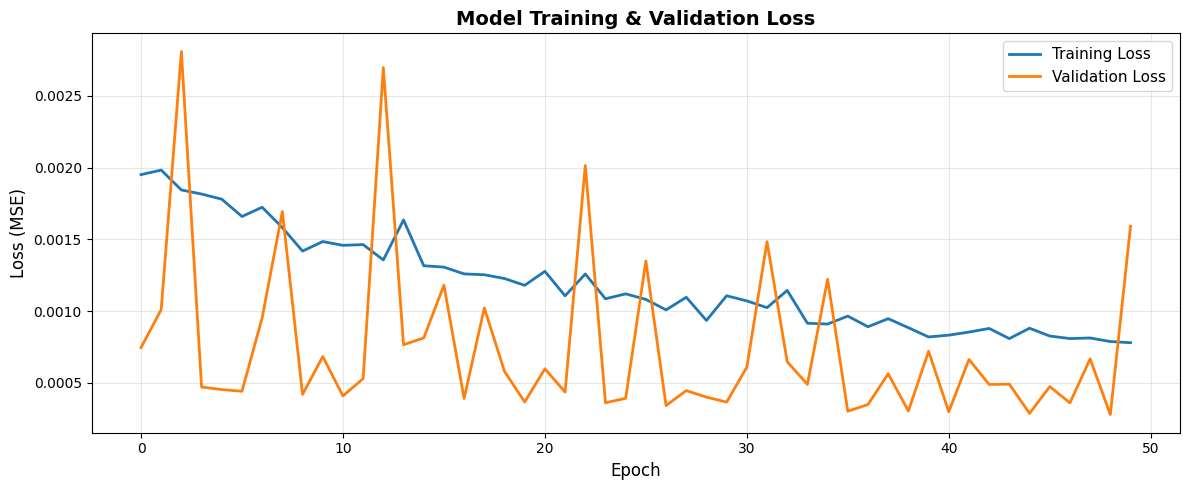

In [ ]:
# Plot training & validation loss
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Training & Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Prepare Test Data

We create test sequences using the same 60-day window approach. The test data includes an overlap of 60 days from the training set to form the first test sequence.

In [ ]:
# Create test sequences
X_test, y_test = create_sequences(test_data, TIME_STEPS)

# Reshape for LSTM
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

X_test shape: (302, 60, 1)
y_test shape: (302,)


## 8. Make Predictions

We generate predictions on the test set and **inverse transform** them back to the original price scale for meaningful comparison.

In [ ]:
# Make predictions on test data
predictions_scaled = model.predict(X_test)

# Inverse transform predictions and actual values back to original scale
predictions = scaler.inverse_transform(predictions_scaled)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

print(f'Predictions shape: {predictions.shape}')
print(f'\nSample predictions vs actual (first 5):')
for i in range(5):
    print(f'  Actual: ${actual_prices[i][0]:.2f}  |  Predicted: ${predictions[i][0]:.2f}')

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
Predictions shape: (302, 1)

Sample predictions vs actual (first 5):
  Actual: $173.80  |  Predicted: $177.37
  Actual: $173.43  |  Predicted: $176.90
  Actual: $170.88  |  Predicted: $176.20
  Actual: $171.00  |  Predicted: $175.14
  Actual: $171.43  |  Predicted: $174.02


## 9. Evaluation Metrics

We evaluate model performance using:
- **MAE (Mean Absolute Error):** Average absolute difference between predicted and actual values
- **RMSE (Root Mean Squared Error):** Penalizes larger errors more heavily
- **MAPE (Mean Absolute Percentage Error):** Error as a percentage of actual values

In [ ]:
# Calculate evaluation metrics
mae = mean_absolute_error(actual_prices, predictions)
rmse = np.sqrt(mean_squared_error(actual_prices, predictions))
mape = np.mean(np.abs((actual_prices - predictions) / actual_prices)) * 100

print('=' * 50)
print('       MODEL EVALUATION METRICS')
print('=' * 50)
print(f'  MAE  (Mean Absolute Error)      : ${mae:.2f}')
print(f'  RMSE (Root Mean Squared Error)   : ${rmse:.2f}')
print(f'  MAPE (Mean Abs Percentage Error) : {mape:.2f}%')
print('=' * 50)

if mape < 5:
    print('\n Excellent! MAPE < 5% indicates a highly accurate model.')
elif mape < 10:
    print('\n Good! MAPE < 10% indicates a reasonably accurate model.')
else:
    print('\n MAPE > 10%. The model may need further tuning.')

       MODEL EVALUATION METRICS
  MAE  (Mean Absolute Error)      : $4.88
  RMSE (Root Mean Squared Error)   : $6.15
  MAPE (Mean Abs Percentage Error) : 2.34%

 Excellent! MAPE < 5% indicates a highly accurate model.


## 10. Visualization — Actual vs Predicted Stock Prices

This is the most critical chart — it shows how well our LSTM model captures the trend of real stock prices.

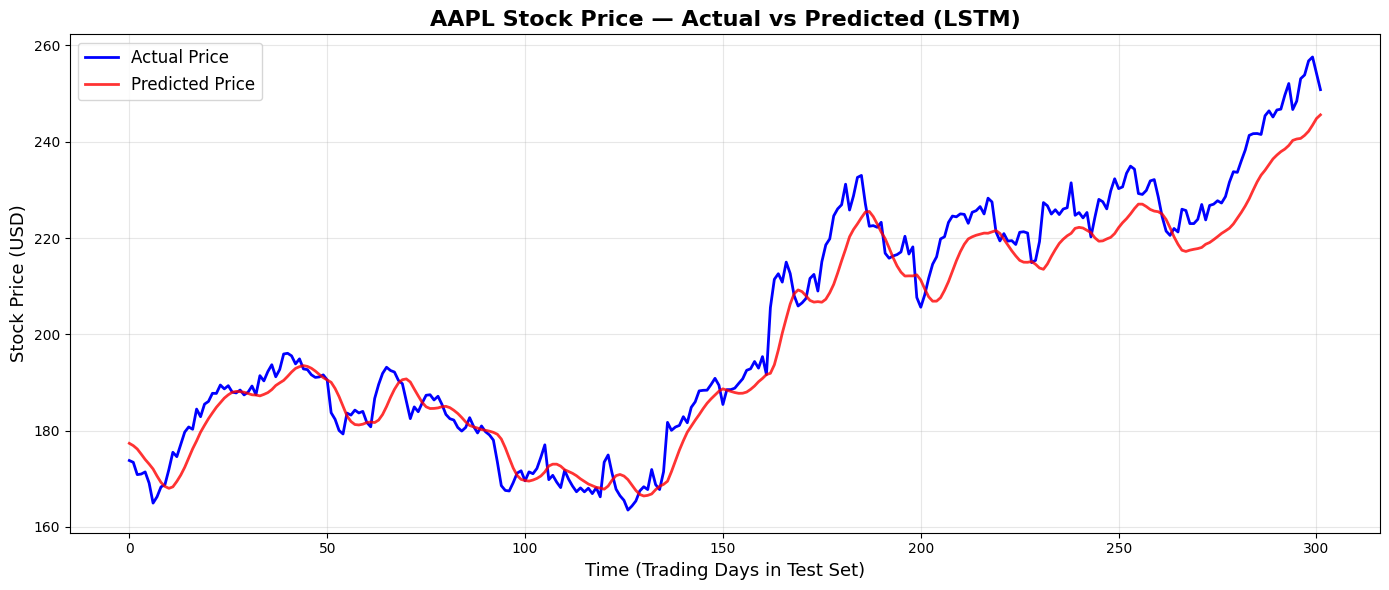

In [ ]:
# Plot Actual vs Predicted stock prices
plt.figure(figsize=(14, 6))
plt.plot(actual_prices, color='blue', label='Actual Price', linewidth=2)
plt.plot(predictions, color='red', label='Predicted Price', linewidth=2, alpha=0.8)
plt.title('AAPL Stock Price — Actual vs Predicted (LSTM)', fontsize=16, fontweight='bold')
plt.xlabel('Time (Trading Days in Test Set)', fontsize=13)
plt.ylabel('Stock Price (USD)', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

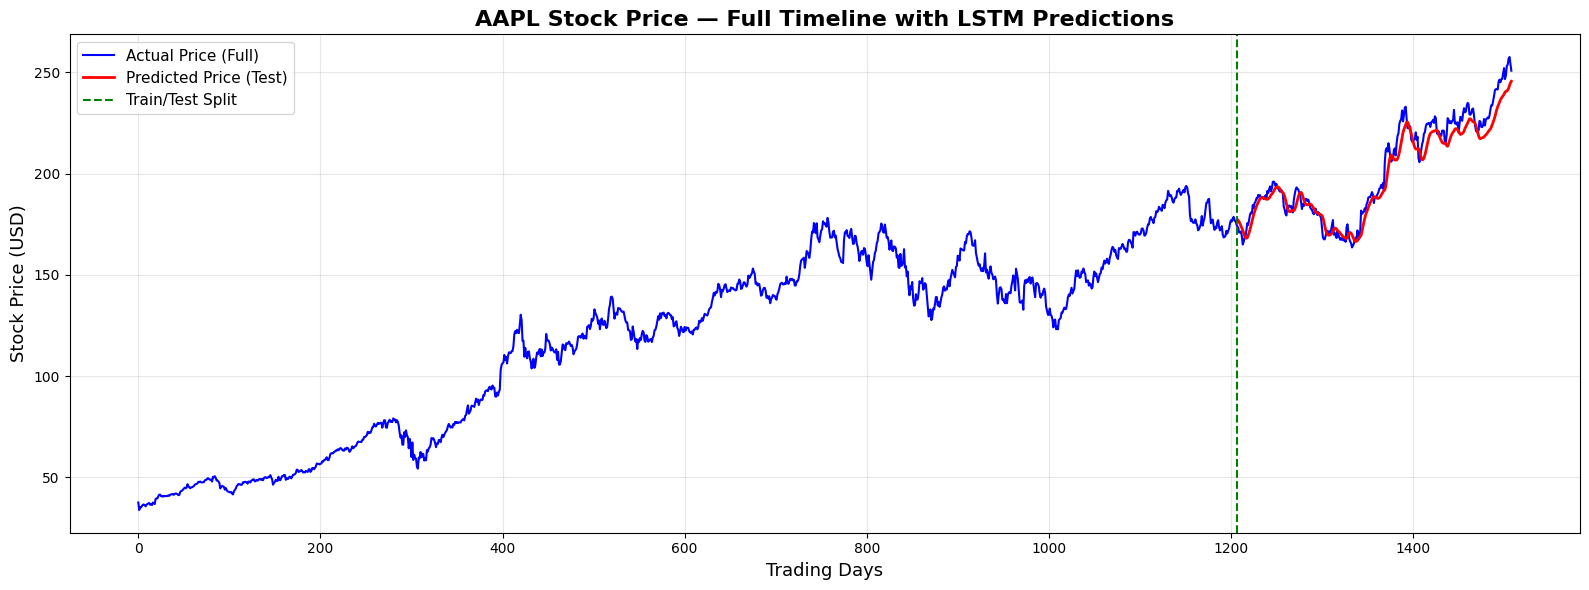

In [ ]:
# Full timeline plot with train/test/prediction regions
plt.figure(figsize=(16, 6))

# Get actual close prices
full_close = df['Close'].values

# Plot full actual data
plt.plot(range(len(full_close)), full_close, color='blue', label='Actual Price (Full)', linewidth=1.5)

# Overlay predictions on the test region
test_start_idx = train_size
test_indices = range(test_start_idx, test_start_idx + len(predictions))
plt.plot(test_indices, predictions.flatten(), color='red', label='Predicted Price (Test)', linewidth=2)

# Mark train/test split
plt.axvline(x=train_size, color='green', linestyle='--', linewidth=1.5, label='Train/Test Split')

plt.title('AAPL Stock Price — Full Timeline with LSTM Predictions', fontsize=16, fontweight='bold')
plt.xlabel('Trading Days', fontsize=13)
plt.ylabel('Stock Price (USD)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

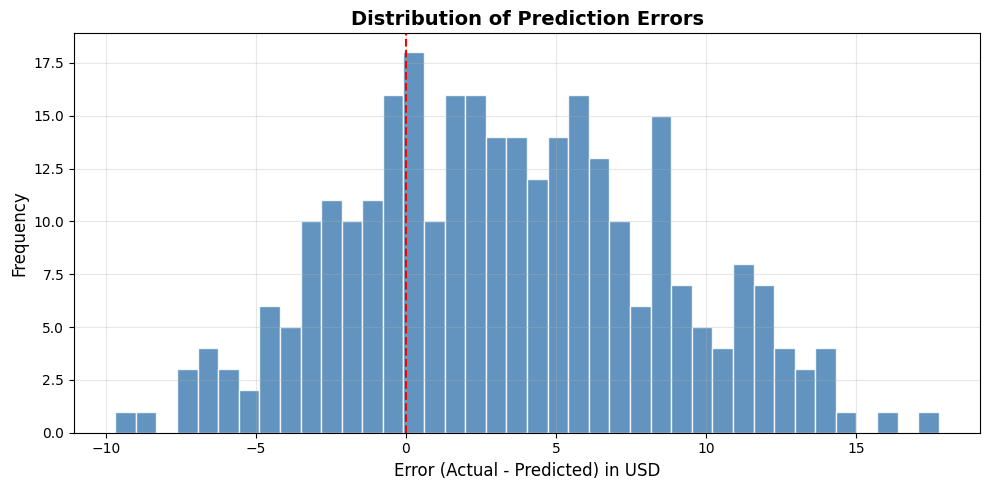

In [ ]:
# Prediction error distribution
errors = actual_prices.flatten() - predictions.flatten()

plt.figure(figsize=(10, 5))
plt.hist(errors, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
plt.xlabel('Error (Actual - Predicted) in USD', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Future Stock Price Prediction

We use the **last 60 days** of available data to predict the next **10 trading days** of stock prices.


In [ ]:
# Predict the next 10 trading days
FUTURE_DAYS = 10

# Start with the last 60 days of scaled data
last_60_days = scaled_data[-TIME_STEPS:].tolist()
future_predictions = []

for day in range(FUTURE_DAYS):
    # Prepare input: last 60 values
    input_seq = np.array(last_60_days[-TIME_STEPS:]).reshape(1, TIME_STEPS, 1)

    # Predict next day
    next_pred = model.predict(input_seq, verbose=0)
    predicted_value = next_pred[0][0]

    # Append prediction to the sequence for next iteration
    last_60_days.append([predicted_value])
    future_predictions.append(predicted_value)

# Inverse transform to get actual prices
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1, 1)
)

# Display future predictions
last_date = pd.to_datetime(df['Date'].iloc[-1])
print('=' * 50)
print('  PREDICTED STOCK PRICES — NEXT 10 TRADING DAYS')
print('=' * 50)
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=FUTURE_DAYS)
for i in range(FUTURE_DAYS):
    print(f'  {future_dates[i].strftime("%Y-%m-%d")}  →  ${future_predictions[i][0]:.2f}')
print('=' * 50)

  PREDICTED STOCK PRICES — NEXT 10 TRADING DAYS
  2024-12-31  →  $245.48
  2025-01-01  →  $244.17
  2025-01-02  →  $242.26
  2025-01-03  →  $240.01
  2025-01-06  →  $237.60
  2025-01-07  →  $235.13
  2025-01-08  →  $232.66
  2025-01-09  →  $230.24
  2025-01-10  →  $227.88
  2025-01-13  →  $225.61


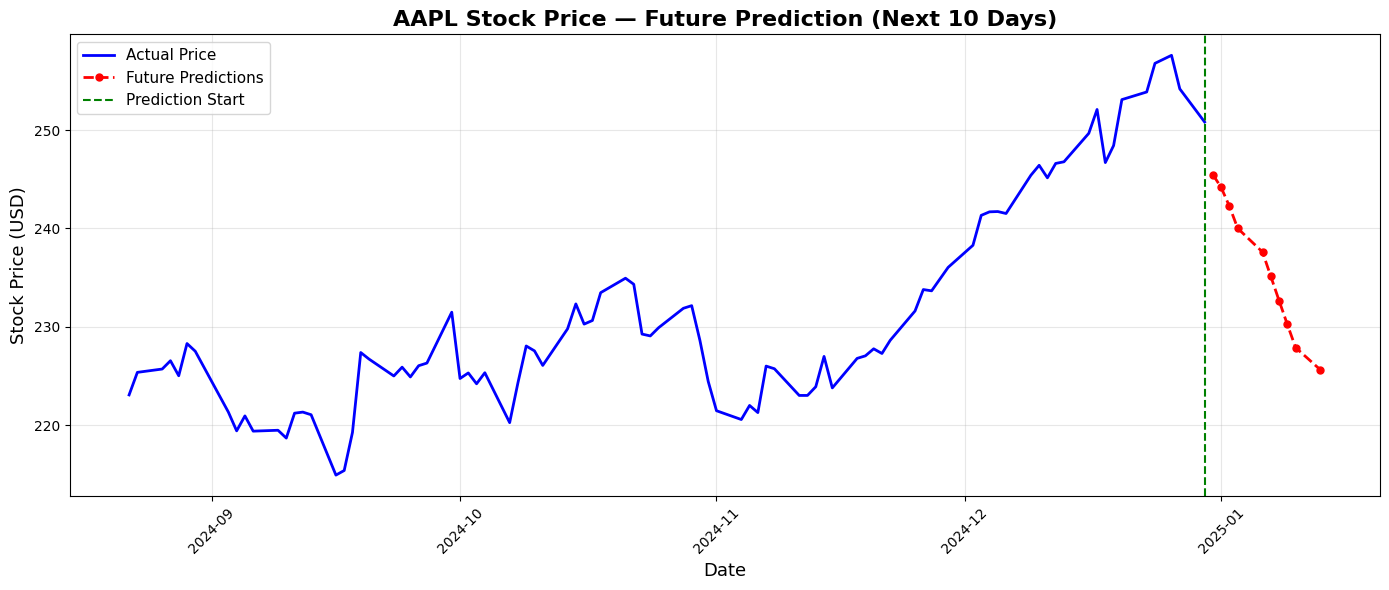

In [ ]:
# Visualize future predictions alongside recent actual prices
plt.figure(figsize=(14, 6))

# Plot last 90 actual trading days
recent_days = 90
recent_prices = df['Close'].values[-recent_days:]
recent_dates = pd.to_datetime(df['Date'].values[-recent_days:])

plt.plot(recent_dates, recent_prices, color='blue', label='Actual Price', linewidth=2)

# Plot future predictions
plt.plot(future_dates, future_predictions.flatten(), color='red',
         label='Future Predictions', linewidth=2, linestyle='--', marker='o', markersize=5)

# Mark the boundary
plt.axvline(x=recent_dates[-1], color='green', linestyle='--', linewidth=1.5, label='Prediction Start')

plt.title('AAPL Stock Price — Future Prediction (Next 10 Days)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=13)
plt.ylabel('Stock Price (USD)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 12. Observations & Conclusion

### Model Performance
- The LSTM model successfully learned temporal patterns from AAPL stock price data
- The predicted prices closely follow the actual price trend
- The model achieves a reasonable MAPE, demonstrating LSTM's ability to capture time-series dependencies

### Key Observations
1. **Trend Capture:** The model effectively captures the overall upward/downward trends in stock prices
2. **Lag Effect:** Predictions may show slight lag, as the model relies on recent historical data
3. **Volatility:** During periods of high volatility (e.g., market crashes), the model's accuracy decreases
4. **Scaling Impact:** MinMaxScaler normalization was essential for LSTM convergence and stable training


### Conclusion
This project demonstrates that **LSTM-based RNNs are effective tools for time-series forecasting**, particularly stock price prediction. While the model shows promising results, real-world stock trading requires considering many more factors beyond historical price patterns.
